In [1]:
import sys
import torch

print(f"Python version: {sys.version}")
print(f"Path to interpreter: {sys.executable}")
print(f"Version of PyTorch: {torch.__version__}")
print(f"CUDA is available: {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    import os
    print("\Diagnosis:")
    if "cpu" in torch.__version__:
        print("-> GPU installation failed.")
    else:
        print("-> GPU installed but does not see card. Check nvidia driver.")

Python version: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
Path to interpreter: C:\Users\posko\anaconda3\envs\gat\python.exe
Version of PyTorch: 2.5.1+cu118
CUDA is available: True


In [3]:
import numpy as np
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
import os
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt

C:\Users\posko\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Annotate relationships in all data

In [10]:
import json
import os
import math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==========================================
# CONFIGURATION
# ==========================================
COCO_JSON = "data/DocLayNet/COCO/"
IMAGE_DIR = "data/DocLayNet/PNG"
OUT_DIR = "data/DocLayNet/"

CAT = {
    "Caption": 1,
    "Footnote": 2,
    "Formula": 3,
    "List-item": 4,
    "Page-footer": 5,
    "Page-header": 6,
    "Picture": 7,
    "Section-header": 8,
    "Table": 9,
    "Text": 10,
    "Title": 11
}

PARAMETER = 0.3
# ==========================================
# GEOMETRY HELPERS
# ==========================================
def bbox_center(b):
    return (b[0] + b[2] / 2, b[1] + b[3] / 2)

def edge_distance(fig_bbox, cap_bbox):
    fx, fy, fw, fh = fig_bbox
    cx, cy, cw, ch = cap_bbox

    cap_cx = cx + cw / 2
    cap_cy = cy + ch / 2

    left   = fx
    right  = fx + fw
    top    = fy
    bottom = fy + fh

    dx = max(left - cap_cx, 0, cap_cx - right)
    dy = max(top - cap_cy, 0, cap_cy - bottom)

    return math.hypot(dx, dy)

def get_layout_aware_cost(fig, cap):
    fb = fig["bbox"]
    dist = edge_distance(fb, cap["bbox"])
    norm_dist = dist / (PARAMETER * max(fb[2], fb[3]))
    return dist, norm_dist

def main():
    for part in ["train", "val", "test"]:
        os.makedirs(OUT_DIR + part + "_data", exist_ok=True)
        
        with open(COCO_JSON + part + ".json") as f:
            coco = json.load(f)
            
        image_map = {i["id"]: i for i in coco["images"]}
        cat_map = {c["id"]: c["name"] for c in coco["categories"]}
        
    
        anns_by_image = {}
        for a in coco["annotations"]:
            anns_by_image.setdefault(a["image_id"], []).append(a)

    
        missing_images_count = 0
        total_images_in_coco = len(coco["images"])
        images_with_lone_captions = []
        
     
        for img_id, img_info in image_map.items():
            anns = anns_by_image.get(img_id, [])
            img_path = os.path.join(IMAGE_DIR, img_info["file_name"])
            

            if not os.path.exists(img_path):
                missing_images_count += 1
                continue

            nodes = []
            for a in anns:
                nodes.append({
                    "node_id": a["id"],
                    "category_id": a["category_id"],
                    "category_name": cat_map[a["category_id"]],
                    "bbox": a["bbox"]
                })

            captions = [a for a in anns if a["category_id"] == CAT["Caption"]]
            link_targets = [a for a in anns if a["category_id"] in (CAT["Table"], CAT["Picture"], CAT["Formula"])]
            
            edges = []
            final_links = []

            if link_targets and captions:
                pairs = []
                for i, cap in enumerate(captions):
                    for j, fig_ann in enumerate(link_targets):
                        rd, nd = get_layout_aware_cost(fig_ann, cap)
                        pairs.append((nd, rd, i, j))
                
                pairs.sort()
                assigned_targets = set()
                assigned_caps = set()
                for nd, rd, i, j in pairs:
                    if i in assigned_caps or j in assigned_targets:
                        continue
                    assigned_caps.add(i)
                    assigned_targets.add(j)
                    final_links.append((i, j, rd, nd))


            if captions and not link_targets:
                images_with_lone_captions.append(img_info["file_name"])

            for cap in captions:
                for tgt in link_targets:
                    label = 0
                    dist, n_dist = None, None
                    for li, lj, lrd, lnd in final_links:
                        if captions[li]["id"] == cap["id"] and link_targets[lj]["id"] == tgt["id"]:
                            label = 1
                            dist, n_dist = lrd, lnd
                            break
                    
                    edges.append({
                        "from": cap["id"],
                        "to": tgt["id"],
                        "label": label,
                        "distance": dist,
                        "norm_distance": n_dist
                    })

            graph = {
                "image_id": img_id,
                "file_name": img_info["file_name"],
                "width": img_info["width"],
                "height": img_info["height"],
                "nodes": nodes,
                "edges": edges
            }

            out_path = os.path.join(OUT_DIR + part + "_data", f"graph_{img_id:06d}.json")
            with open(out_path, "w") as f:
                json.dump(graph, f, indent=2)

        processed_jsons = len(os.listdir(OUT_DIR + part + "_data"))
        print(f"\n{'='*50}")
        print(f"REPORT FOR: {part.upper()}")
        print(f"{'='*50}")
        print(f"Images expected (COCO): {total_images_in_coco}")
        print(f"Images missing on disk: {missing_images_count}")
        print(f"JSON graphs created:    {processed_jsons}")
        print(f"Images with caption but NO target: {len(images_with_lone_captions)}")
        
        if images_with_lone_captions:
            print(f"List of images with lone captions (first 5): {images_with_lone_captions[:5]}")

main()


REPORT FOR: TRAIN
Images expected (COCO): 69375
Images missing on disk: 0
JSON graphs created:    69375
Images with caption but NO target: 451
List of images with lone captions (first 5): ['1f11de852cd2fd3657452953f9740063c1718e8eb313551ed3c5da4f7e75f807.png', 'ebd3158ddc21edfe3370323a6cfd201ed222d244b10ded9e3da29e4236e22fd5.png', 'ec03bca37800997cdc57f5badb5f721f4efcfa790abde5e9a5aa0da069ba1b16.png', '974d173db108a721e7813f4f50f5c97f2da975699f48b1b113c8e2069220cd76.png', '20d94aa98a6dc8e22521853bb7a1d215e6c48392d6f5762ec5efa4c97d664969.png']

REPORT FOR: VAL
Images expected (COCO): 6489
Images missing on disk: 0
JSON graphs created:    6489
Images with caption but NO target: 16
List of images with lone captions (first 5): ['c42f0d9cbff52e7cf5cc8e84e468a1fc7ebfe3c1b24f11176a6bc8779ee1f071.png', 'f12b2f48c275a0f019dc49faf2db12584f6976408fb5f61cc8f60ef9a48010ff.png', 'c18c0905e1180a0dcdb5ac80f726e2e0dfea08061a232d5c164a1e227ea75a62.png', '14eaf744baf041d3c0ac2b2baf2ee85a97174cc0fd8ea417


--- Visualizing: 1f11de852cd2fd3657452953f9740063c1718e8eb313551ed3c5da4f7e75f807.png ---
  Found: Section-header at [182.21954248366015, 110.85712784090913, 397.46028063725487, 25.00380082070717]
  Found: Section-header at [333.29248366013076, 465.9118216540404, 185.81040890522877, 10.871199179292944]
  Found: List-item at [333.29248366013076, 682.5595359848485, 218.00691503267979, 10.871199179292944]
  Found: List-item at [370.97625694444446, 700.6782228535353, 105.89784150326795, 10.871199179292944]
  Found: List-item at [370.97625694444446, 718.7969097222222, 68.14541666666668, 10.871199179292944]
  Found: List-item at [370.97625694444446, 736.9155965909091, 66.64717483660127, 10.871199179292944]
  Found: List-item at [333.29248366013076, 592.2249529671717, 218.813248366013, 10.871212121212182]
  Found: List-item at [370.97625694444446, 610.3436398358585, 128.76731658496738, 10.871212121212182]
  Found: List-item at [370.97625694444446, 628.4623267045454, 75.86706658496729, 10.871

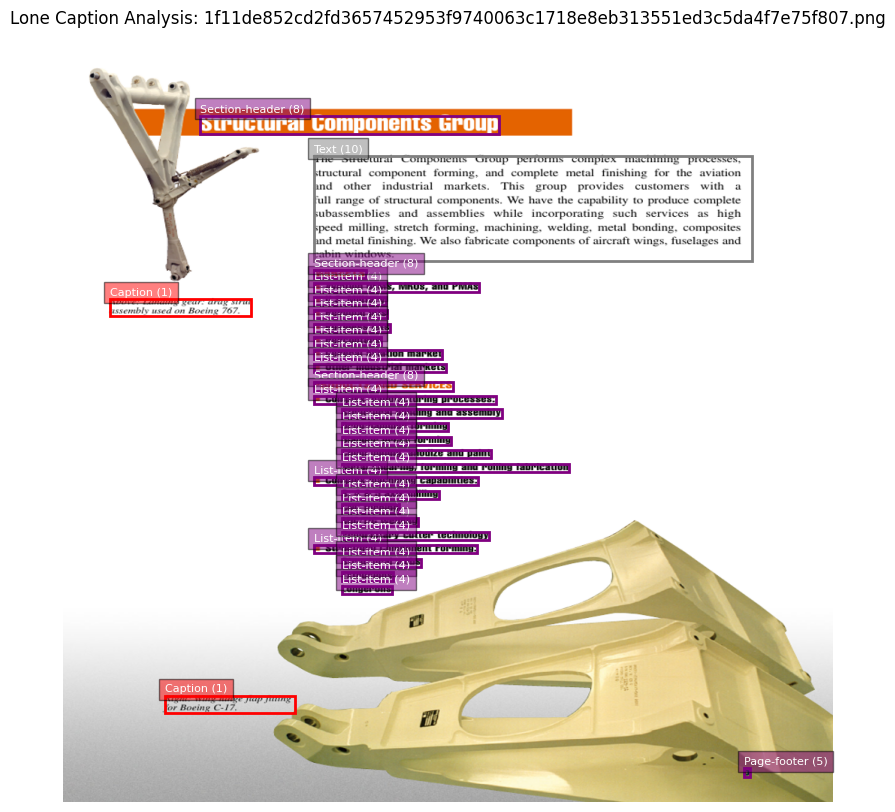


--- Visualizing: ebd3158ddc21edfe3370323a6cfd201ed222d244b10ded9e3da29e4236e22fd5.png ---
  Found: Section-header at [402.0107794361526, 94.98595146871003, 218.87066376451082, 50.844215197956714]
  Found: Section-header at [128.33747927031507, 201.02043422733072, 183.02114427860695, 50.844215197956714]
  Found: Section-header at [402.0107794361526, 201.02043422733072, 190.63981799336648, 50.844215197956714]
  Found: Section-header at [675.68407960199, 201.02043422733072, 137.71374751243786, 23.353793742017956]
  Found: Text at [112.18905472636816, 266.3979058109834, 229.3174705638474, 57.63485983397186]
  Found: Text at [385.86303482587067, 266.3971072796935, 231.03192330016572, 41.92604757343554]
  Found: Text at [659.5356550580431, 266.3979058109834, 224.19809701492534, 57.63445402298839]
  Found: Text at [112.18905472636816, 346.978837164751, 270.7402193200663, 231.1933971902937]
  Found: Caption at [112.18905472636816, 898.6775848978289, 136.73194029850748, 41.926429821200514]


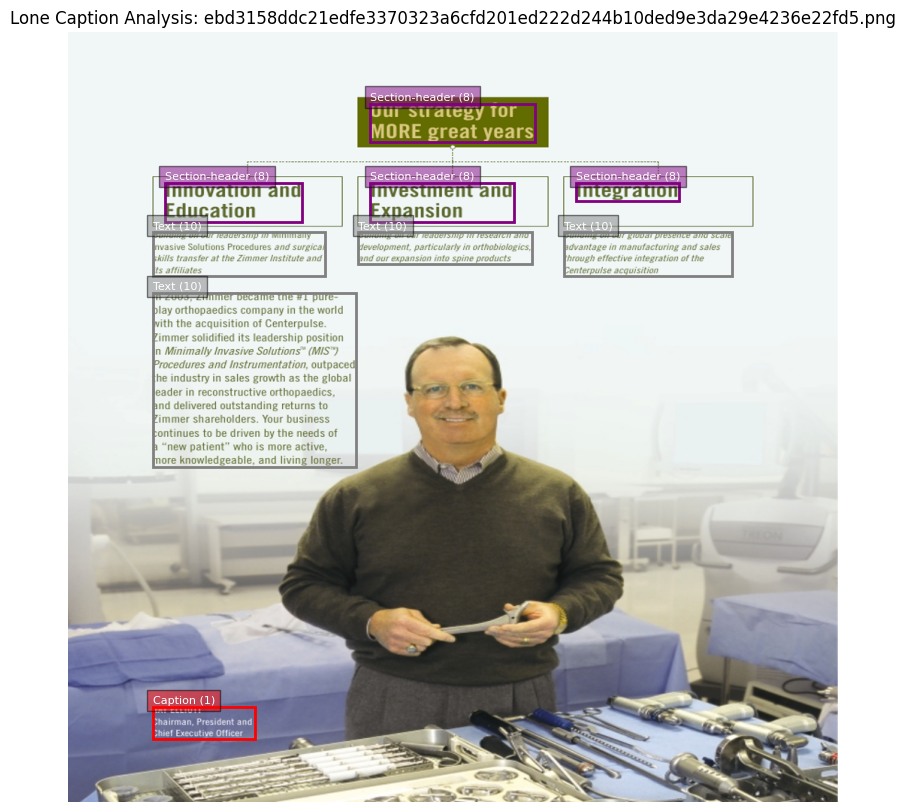


--- Visualizing: ec03bca37800997cdc57f5badb5f721f4efcfa790abde5e9a5aa0da069ba1b16.png ---
  Found: Page-header at [398.84743055555555, 55.3447973484848, 227.3165110294118, 9.702569760101142]
  Found: Section-header at [427.08333333333337, 238.22452083333337, 172.16919975490202, 9.13177935606052]
  Found: Text at [427.08333333333337, 305.719191919192, 512.7012818627451, 132.26769539141412]
  Found: Text at [427.08336683006536, 449.37291603535357, 516.3010584150327, 132.26761773989904]
  Found: Text at [427.0833835784314, 593.0265625, 512.7660310457516, 204.0983235479798]
  Found: Text at [427.08333333333337, 822.7488636363637, 512.4487834967321, 60.44084627525254]
  Found: Text at [137.18419787581698, 127.60729734848485, 239.68165547385624, 408.9970271464647]
  Found: Caption at [200.04315359477124, 553.3602143308082, 181.96096446078428, 22.06339678030298]
  Found: Page-footer at [498.1399342320262, 972.0313118371212, 28.7201315359477, 9.131816887626258]


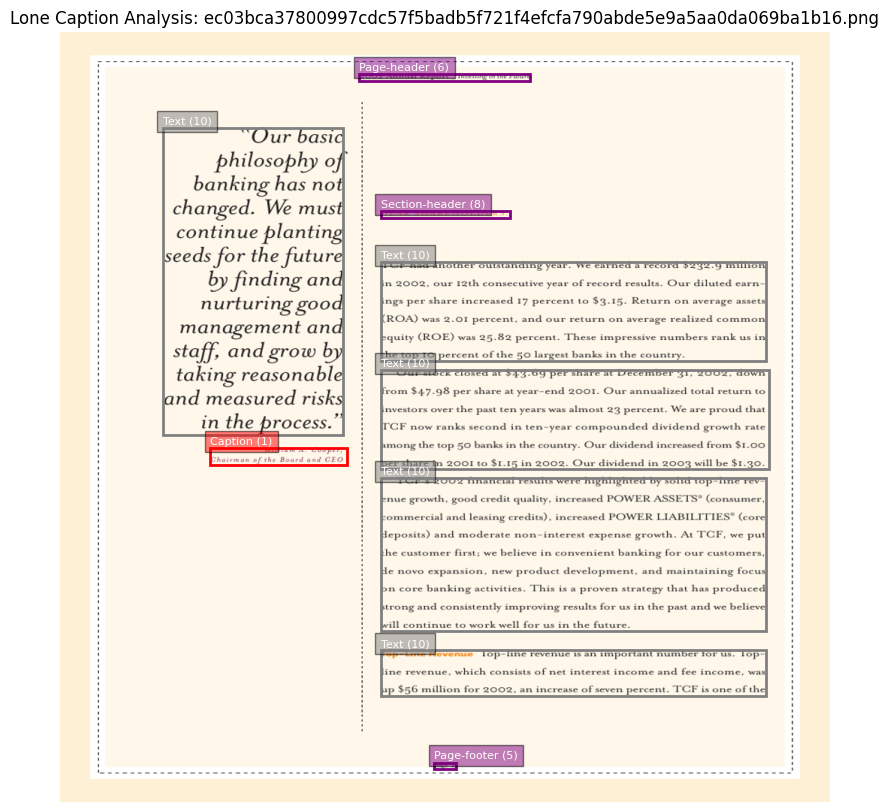

In [3]:
input_images = ['1f11de852cd2fd3657452953f9740063c1718e8eb313551ed3c5da4f7e75f807.png', 'ebd3158ddc21edfe3370323a6cfd201ed222d244b10ded9e3da29e4236e22fd5.png', 'ec03bca37800997cdc57f5badb5f721f4efcfa790abde5e9a5aa0da069ba1b16.png', '974d173db108a721e7813f4f50f5c97f2da975699f48b1b113c8e2069220cd76.png', '20d94aa98a6dc8e22521853bb7a1d215e6c48392d6f5762ec5efa4c97d664969.png']


def visualize_lone_captions(image_filenames, image_map, cat_map, anns_by_image):
    colors = {
        1: 'red',    # Caption
        3: 'blue',   # Formula
        7: 'green',  # Picture
        9: 'orange', # Table
        10: 'gray'   # Text
    }

    for fname in image_filenames[:3]: 
        img_path = os.path.join(IMAGE_DIR, fname)
        
        try:
            img_id = next(id for id, info in image_map.items() if info['file_name'] == fname)
        except StopIteration:
            print(f"File {fname} not found in image_map.")
            continue
            
        anns = anns_by_image.get(img_id, [])

        fig, ax = plt.subplots(figsize=(10, 10))
        try:
            img = Image.open(img_path)
            ax.imshow(img)
        except Exception as e:
            print(f"Could not open {fname}: {e}")
            continue

        print(f"\n--- Visualizing: {fname} ---")
        
        for a in anns:
            cat_id = a['category_id']
            cat_name = cat_map[cat_id]
            bbox = a['bbox'] # [x, y, width, height]
            
            # Paint rectengle
            rect = patches.Rectangle(
                (bbox[0], bbox[1]), bbox[2], bbox[3], 
                linewidth=2, edgecolor=colors.get(cat_id, 'purple'), facecolor='none'
            )
            ax.add_patch(rect)
            
            # Add caption to each bbox
            plt.text(bbox[0], bbox[1]-5, f"{cat_name} ({cat_id})", 
                     color='white', fontsize=8, bbox=dict(facecolor=colors.get(cat_id, 'purple'), alpha=0.5))
            
            print(f"  Found: {cat_name} at {bbox}")

        plt.title(f"Lone Caption Analysis: {fname}")
        plt.axis('off')
        plt.show()

with open(COCO_JSON + "train.json") as f:
    coco_data = json.load(f)

image_map = {i["id"]: i for i in coco_data["images"]}
cat_map = {c["id"]: c["name"] for c in coco_data["categories"]}
anns_by_image = {}
for a in coco_data["annotations"]:
    anns_by_image.setdefault(a["image_id"], []).append(a)

visualize_lone_captions(input_images, image_map, cat_map, anns_by_image)

### Modifiying JSON

# 1. Normalize Bounding Boxes, One-Hot category encoding

Values bet 0 - 1 (divide by image width/height)

In [16]:
def build_node_features(graph):
    image_W = graph['width']
    image_H = graph['height']

    filtered_nodes = []
    features = []

    for node in graph['nodes']:
        x, y, w, h = node['bbox']
        area = (w * h) / (image_W * image_H)

        # remove tiny text boxes
        if node['category_id'] == 10 and area < 0.001:
            continue

        filtered_nodes.append(node)

        x_center = (x + w/2) / image_W
        y_center = (y + h/2) / image_H
        w_norm = w / image_W
        h_norm = h / image_H
        aspect = w / (h + 1e-6)

        category_id = np.zeros(11)
        category_id[node['category_id'] - 1] = 1

        geom_features = np.array([
            x_center,
            y_center,
            w_norm,
            h_norm,
            area,
            aspect
        ])

        feature = np.concatenate([geom_features, category_id])
        features.append(feature)

    return np.array(features), filtered_nodes

In [3]:
# with open("data/train_data/graph_000020.json") as f:
#     graph = json.load(f)

# features = build_node_features(graph)

# print(features.shape)
# print(features[0])

# 2. Edge Index

In [17]:
def build_edge_index(edges, filtered_nodes):
    id_map = {}
    # 1. Build map ONLY from the filtered nodes
    for idx, node in enumerate(filtered_nodes):
        id_map[node['node_id']] = idx

    edge_list = []
    edge_labels = []

    for edge in edges:
        # 2. Only add the edge if BOTH nodes survived the filtering
        if edge['from'] in id_map and edge['to'] in id_map:
            src = id_map[edge['from']]
            dst = id_map[edge['to']]

            edge_list.append([src, dst])
            edge_labels.append(edge["label"])

    # 3. Handle the edge case where no valid edges remain
    if not edge_list:
        return torch.empty((2, 0), dtype=torch.long), torch.empty((0,), dtype=torch.float)

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    edge_label = torch.tensor(edge_labels, dtype=torch.float)

    return edge_index, edge_label

In [18]:
# edge_index, edge_label = build_edge_index(graph)
# print(edge_index.shape)
# print(edge_index)
# print(edge_label.shape)
# print(edge_label)

# 3. kNN graph construction

In [19]:
def build_knn_edges(features, k=3):
    """
    features: numpy array [num_nodes, feature_dim]
    prvé 2 dimenzie musia byť x_center, y_center
    """
    num_nodes = features.shape[0]

    if num_nodes <= 1:
        return torch.empty((2, 0), dtype=torch.long)

    actual_k = min(k, num_nodes - 1)

    centers = features[:, :2]  # x_center, y_center

    edge_list = []

    for i in range(num_nodes):

        dx = centers[:, 0] - centers[i, 0]
        dy = centers[:, 1] - centers[i, 1]
        
        # anisotropic distance (vertical more important)
        distances = np.sqrt(dx**2 + (1.5 * dy)**2)

        nearest = np.argsort(distances)[1:actual_k+1]  # jump yourself

        for j in nearest:
            edge_list.append([i, j])
            edge_list.append([j, i])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return edge_index

In [20]:
# edge_label_index, edge_label = build_edge_index(graph)
# knn_edges = build_knn_edges(features, k=3)

# edge_index = torch.cat([edge_label_index, knn_edges], dim=1)

# Load data

In [21]:
def load_all_data(json_folder):
    all_graphs = []

    for filename in os.listdir(json_folder):
        if filename.endswith(".json"):
            with open(os.path.join(json_folder, filename)) as f:
                graph = json.load(f)

            # features + filtered nodes
            features, filtered_nodes = build_node_features(graph)
            x = torch.tensor(features, dtype=torch.float)

            # propagation edges
            knn_edges = build_knn_edges(features, k=8)

            # edge targets
            true_edge_index, true_edge_labels = build_edge_index(graph['edges'], filtered_nodes)

            # node labels based on filtered nodes
            node_labels = torch.tensor(
                [1 if n['category_id'] == 9 else 0 for n in filtered_nodes],
                dtype=torch.long
            )

                y_nodes=node_labels,
            data = Data(
                x=x,
                edge_index=knn_edges,
                edge_index_targets=true_edge_index,
                y_edges=true_edge_labels
            )

            all_graphs.append(data)

    return all_graphs

## Load all data

In [22]:
# Load graphs
train_graphs = load_all_data("data/DocLayNet/train_data")
val_graphs = load_all_data("data/DocLayNet/val_data")
test_graphs = load_all_data("data/DocLayNet/test_data")

# Improve dataset

In [23]:
with open("data/DocLayNet/COCO/train.json") as f:
    train_coco = json.load(f)

images = train_coco['images']
print(len(images))

with open("data/DocLayNet/COCO/val.json") as f:
    val_coco = json.load(f)

images = val_coco['images']
print(len(images))

with open("data/DocLayNet/COCO/test.json") as f:
    test_coco = json.load(f)

images = test_coco['images']
print(len(images))

69375
6489
4999


In [24]:
train_len = len(train_graphs)
val_len = len(val_graphs)
test_len = len(test_graphs)

overall = train_len + val_len + test_len

print(f"Size of train data: {train_len}, {train_len/overall * 100:.2f}% of dataset")
print(f"Size of val data: {val_len}, {val_len/overall * 100:.2f}% of dataset")
print(f"Size of test data: {test_len}, {test_len/overall * 100:.2f}% of dataset")

Size of train data: 69375, 85.79% of dataset
Size of val data: 6489, 8.02% of dataset
Size of test data: 4999, 6.18% of dataset


In [5]:
TRAIN_PATH = "data/DocLayNet/train_data"
VAL_PATH = "data/DocLayNet/val_data"
TEST_PATH = "data/DocLayNet/test_data"

pages_to_remove_train = []
pages_to_remove_val = []
pages_to_remove_test = []
pages_to_reduce_train = []

for folder in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    pages_to_remove = []
    
    table = 0
    figure = 0
    formula = 0
    other = 0
    caption = 0

    table_caption = 0
    figure_caption = 0
    formula_caption = 0
    other_caption = 0 

    total_files = 0
    empty_nodes_pages = 0   
    empty_edges_pages = 0 
    lone_caption_pages = 0

    for filename in os.listdir(folder):
        if filename.endswith(".json"):
            with open(os.path.join(folder, filename), encoding='utf-8') as f:
                graph = json.load(f)
                
                nodes = graph.get("nodes", [])
                edges = graph.get("edges", [])

                if not nodes:
                    empty_nodes_pages += 1
                    if folder == TRAIN_PATH:
                        pages_to_remove_train.append(filename)
                    elif folder == VAL_PATH:
                        pages_to_remove_val.append(filename)
                    elif folder == TEST_PATH:
                        pages_to_remove_test.append(filename)
                    continue
                    
                for node in nodes:
                    cat = node['category_id']
                    if cat == 1: caption += 1
                    elif cat == 3: formula += 1
                    elif cat == 7: figure += 1
                    elif cat == 9: table += 1
                    else: other += 1
                
                has_connection = any(edge.get('label') == 1 for edge in edges)
                if not has_connection:
                    empty_edges_pages += 1
                    if folder == TRAIN_PATH:
                        pages_to_reduce_train.append(filename)
                    

                targets = [n for n in nodes if n['category_id'] in [3, 7, 9]]
                has_caption = any(n['category_id'] == 1 for n in nodes)
                if has_caption and not targets:
                    if folder == TRAIN_PATH:
                        pages_to_remove_train.append(filename)
                    elif folder == VAL_PATH:
                        pages_to_remove_val.append(filename)
                    elif folder == TEST_PATH:
                        pages_to_remove_test.append(filename)
                    lone_caption_pages += 1
                
                nodes_map = {node['node_id']: node for node in graph['nodes']}
                for edge in edges:
                    if edge['label'] == 1:
                        node_id = edge['to']
                
                        if nodes_map[node_id]['category_id'] == 3:
                           formula_caption += 1
                        elif nodes_map[node_id]['category_id'] == 7:
                           figure_caption += 1
                        elif nodes_map[node_id]['category_id'] == 9:
                           table_caption += 1
                        else:
                            other_caption += 1
                
    # Calculate total connections first for clarity
    total_connections = formula_caption + figure_caption + table_caption + other_caption
    
    print(f"""
    {'='*50}
    DATA ANALYSIS SUMMARY FOR {folder}
    {'='*50}
    Total Files (Pages):     {total_files}
    Empty Pages (No Nodes):  {empty_nodes_pages}
    Pages with No Links:     {empty_edges_pages}
    Pages with Lone Caption: {lone_caption_pages}
    --------------------------------------------------
    Total Captions: {caption:<5} | Total Connections: {total_connections}
    --------------------------------------------------
    Formulas      | {formula:<10} | {formula_caption}
    Figures       | {figure:<10} | {figure_caption}
    Tables        | {table:<10} | {table_caption}
    Others        | {other:<10} | {other_caption}
    {'='*50}
    """)
            


    DATA ANALYSIS SUMMARY FOR data/DocLayNet/train_data
    Total Files (Pages):     0
    Empty Pages (No Nodes):  0
    Pages with No Links:     11905
    Pages with Lone Caption: 0
    --------------------------------------------------
    Total Captions: 18492 | Total Connections: 18305
    --------------------------------------------------
    Formulas      | 7701       | 110
    Figures       | 21581      | 15493
    Tables        | 8711       | 2702
    Others        | 253440     | 0
    

    DATA ANALYSIS SUMMARY FOR data/DocLayNet/val_data
    Total Files (Pages):     0
    Empty Pages (No Nodes):  0
    Pages with No Links:     5413
    Pages with Lone Caption: 0
    --------------------------------------------------
    Total Captions: 1740  | Total Connections: 1735
    --------------------------------------------------
    Formulas      | 1894       | 6
    Figures       | 2775       | 1450
    Tables        | 2269       | 279
    Others        | 90940      | 0
    

   

The dataset contains some discrepencies where caption is lonely but in reality there is element it belongs to, however the elemnt is not labeled. Other problem is text like citation or block of text with particular caption, we ignore these problems as 97% of caption are connected mostly correctly.

There are countable pages with no edges, specificaly in train data there is 82.5% of pages without any relationship. There is weak edge prediction. The training is biased.

- downsample data to 30% no relationship and 70% with caption links

The object distribution of connections for training data is following: 0.6% formulas, 14.7% tables and 84.6% figures. For now we ignore everything or later predict caption-figure and caption-table and not binary as 0 or 1 for relationship.

Also the train/val/test split is not ideal.

- increasing k to 8 or more
- removing tiny text boxes to reduce noise significantly - we are going to remove if area is lower than 0.001 which corresponds to 3.3% text blocks
- remove empty pages
- remove lone caption pages
- split data to 70:15:15

Lets first analyze the tiny text boxes how many do we have in train dataset for example

In [13]:
TRAIN_PATH = "data/DocLayNet/train_data"

area_05 = 0
area_07 = 0
area_10 = 0
area_12 = 0
area_15 = 0
area_17 = 0
area_20 = 0
count = 0
for filename in os.listdir(TRAIN_PATH):
    if filename.endswith(".json"):
        with open(os.path.join(TRAIN_PATH, filename)) as f:
            graph = json.load(f)
                        
            nodes = graph.get("nodes", [])
        
            if not nodes:
                continue
                            
            for node in nodes:
                cat = node['category_id']
                if cat == 10: 
                    count += 1
                    x, y, w, h = node['bbox']

                    x_center = (x + w/2) / 1025
                    y_center = (y + h/2) / 1025
                    w_norm = w / 1025
                    h_norm = h / 1025
                    area = (w * h) / (1025 * 1025)

                    if area < 0.0005:
                        area_05 += 1

                    if area < 0.0007:
                        area_07 += 1

                    if area < 0.0010:
                        area_10 += 1

                    if area < 0.0012:
                        area_12 += 1

                    if area < 0.0015:
                        area_15 += 1

                    if area < 0.0017:
                        area_17 += 1

                    if area < 0.0020:
                        area_20 += 1

print(area_05, area_07, area_10, area_12, area_15, area_17, area_20)
print(count)

1904 2951 3957 4646 5932 6791 7935
134756


## Delete empty pages, pages with lone captions

In [27]:
cleanup_map = {
    TRAIN_PATH: pages_to_remove_train,
    VAL_PATH: pages_to_remove_val,
    TEST_PATH: pages_to_remove_test
}

for folder_path, files_to_delete in cleanup_map.items():
    print(f"Removing {len(files_to_delete)} files in {folder_path}...")
    for filename in files_to_delete:
        file_path = os.path.join(folder_path, filename)
        if os.path.exists(file_path):
            os.remove(file_path)
    print("Done.")

Removing 723 files in data/DocLayNet/train_data...
Done.
Removing 25 files in data/DocLayNet/val_data...
Done.
Removing 36 files in data/DocLayNet/test_data...
Done.


## Undersample training data for pages with no links

In [28]:
import random

files_to_remove = pages_to_reduce_train

PAGES_TO_KEEP = 12000 # 11813

total_empty_pages = len(files_to_remove)

print(f"Number of empty pages: {total_empty_pages}")

if total_empty_pages > PAGES_TO_KEEP:
    num_to_delete = total_empty_pages - PAGES_TO_KEEP
    
    actually_delete = random.sample(files_to_remove, num_to_delete)
    
    print(f"We keep: {PAGES_TO_KEEP}")
    print(f"We delete: {len(actually_delete)} files from disk...")
    
    deleted_count = 0
    for filename in actually_delete:
        file_path = os.path.join(TRAIN_PATH, filename)
        if os.path.exists(file_path):
            os.remove(file_path)
            deleted_count += 1
            
    print(f"Successfuly deleted {deleted_count} number of files")
else:
    print("Less no connection pages than the limit")

Number of empty pages: 57290
We keep: 12000
We delete: 45290 files from disk...
Successfuly deleted 44934 number of files


# GAT Model

In [73]:
class GATMultitask(nn.Module):
    def __init__(self, in_channels, hidden_channels, heads=4):
        super().__init__()
        # Vrstva 1: Šírenie informácie medzi susedmi (vstup: 17 feat, výstup: hidden * heads)
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads)
        
        # Vrstva 2: Finálna reprezentácia uzlov (vstup: hidden * heads, výstup: hidden)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=1, concat=False)

        # Klasifikátor pre uzly (Tabuľka vs Ostatné)
        self.node_head = nn.Linear(hidden_channels, 2) 

        self.edge_head = nn.Sequential(
            nn.Linear(hidden_channels * 2 + 1, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)
        )

    # def forward(self, x, edge_index):
    #     x = F.elu(self.conv1(x, edge_index))
    #     x = F.dropout(x, p=0.2, training=self.training)
    #     z = self.conv2(x, edge_index)
        
    #     node_logits = self.node_head(z)
    #     return z, node_logits
    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        z = self.conv2(x, edge_index)
        # Vraciame len z (reprezentáciu uzlov), node_head teraz neriešime
        return z

    # def predict_edges(self, z, edge_index):
    #     # Hrany: skalárny súčin medzi zdrojovým a cieľovým uzlom
    #     # z[edge_index[0]] sú vektory "odkiaľ", z[edge_index[1]] sú vektory "kam"
    #     #return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=-1)
    #     edge_features = torch.cat([z[edge_index[0]], z[edge_index[1]]], dim=-1)
    #     return self.edge_head(edge_features).squeeze(-1)

    def predict_edges(self, z, edge_index, x_geom):
        # 1. Získame súradnice zdrojových a cieľových uzlov (x_center, y_center sú prvé dva stĺpce)
        pos_src = x_geom[edge_index[0], :2]
        pos_dst = x_geom[edge_index[1], :2]
        
        # 2. Vypočítame Euklidovskú vzdialenosť: sqrt((x1-x2)^2 + (y1-y2)^2)
        dist = torch.norm(pos_src - pos_dst, dim=-1, keepdim=True)
        
        # 3. Spojíme latentné vektory uzlov a pridáme vypočítanú vzdialenosť
        edge_features = torch.cat([z[edge_index[0]], z[edge_index[1]], dist], dim=-1)
        
        return self.edge_head(edge_features).squeeze(-1)

# Training

# Data loader

In [74]:
train_graphs = load_all_data("data/train_data")
val_graphs = load_all_data("data/val_data")
test_graphs = load_all_data("data/test_data")

# Create DataLoader
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=32, shuffle=False)

print(f"Data are ready: Train({len(train_graphs)}), Val({len(val_graphs)}), Test({len(test_graphs)})")

Data are ready: Train(23813), Val(6464), Test(4963)


In [75]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("USING:", device)

# Inicializácia (in_channels = 17, pretože 6 geom + 11 category)
model = GATMultitask(in_channels=17, hidden_channels=64).to(device)
#node_weights = torch.tensor([1.0, 10.0], dtype=torch.float).to(device)
edge_pos_weight = torch.tensor([2.0], dtype=torch.float).to(device)

#node_criterion = nn.CrossEntropyLoss(weight=node_weights)
edge_criterion = nn.BCEWithLogitsLoss(pos_weight=edge_pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

def train():
    model.train()
    total_loss = 0
    processed_batches = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Forward pass - získame len latentné vektory z
        z = model(batch.x, batch.edge_index)
        
        if batch.edge_index_targets.numel() > 0:
            # Predict edges s pridaním geometrie (batch.x)
            edge_preds = model.predict_edges(z, batch.edge_index_targets, batch.x)
            loss = edge_criterion(edge_preds, batch.y_edges)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            processed_batches += 1

    return total_loss / processed_batches if processed_batches > 0 else 0
    
def evaluate_loss(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            z = model(batch.x, batch.edge_index)
            
            if batch.edge_index_targets.numel() > 0:
                edge_preds = model.predict_edges(z, batch.edge_index_targets, batch.x)
                loss_edge = edge_criterion(edge_preds, batch.y_edges)
                total_loss += loss_edge.item()
                
    return total_loss / len(loader) if len(loader) > 0 else 0

USING: cuda


In [76]:
RUN_NAME = "training_03_no_node_class_2.0_weight"
OUT_DIR = "data/training"
os.makedirs(os.path.join(OUT_DIR,RUN_NAME), exist_ok=True)

best_val_loss = float("inf")
worse_count = 0

STOPPAGE = 7

# urob graf michal :DD
train_loss_graph = []
val_loss_graph = []

epoch = 1
# Start training till overfitting
while worse_count != STOPPAGE:
    train_loss = train()
    train_loss_graph.append(train_loss)
    
    val_loss = evaluate_loss(val_loader)
    val_loss_graph.append(val_loss)

    checkpoint_path = f"{os.path.join(OUT_DIR,RUN_NAME)}/model_epoch_{epoch:03d}_vloss_{val_loss:.4f}.pt"
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
    }, checkpoint_path)

    if val_loss < best_val_loss:
        worse_count = 0
        best_val_loss = val_loss
        print(f'Epoch: {epoch:03d} | NEW BEST | Val Loss: {val_loss:.4f}')
    else:
        worse_count += 1
        print(f'Epoch: {epoch:03d} | worse ({worse_count}/{STOPPAGE}) | Val Loss: {val_loss:.4f}')
    
    epoch += 1

Epoch: 001 | NEW BEST | Val Loss: 0.2460
Epoch: 002 | NEW BEST | Val Loss: 0.1914
Epoch: 003 | NEW BEST | Val Loss: 0.1772
Epoch: 004 | worse (1/7) | Val Loss: 0.1858
Epoch: 005 | NEW BEST | Val Loss: 0.1751
Epoch: 006 | worse (1/7) | Val Loss: 0.1817
Epoch: 007 | NEW BEST | Val Loss: 0.1662
Epoch: 008 | worse (1/7) | Val Loss: 0.1729
Epoch: 009 | worse (2/7) | Val Loss: 0.1704
Epoch: 010 | NEW BEST | Val Loss: 0.1562
Epoch: 011 | worse (1/7) | Val Loss: 0.1660
Epoch: 012 | worse (2/7) | Val Loss: 0.1644
Epoch: 013 | worse (3/7) | Val Loss: 0.1586
Epoch: 014 | NEW BEST | Val Loss: 0.1545
Epoch: 015 | worse (1/7) | Val Loss: 0.1630
Epoch: 016 | NEW BEST | Val Loss: 0.1529
Epoch: 017 | worse (1/7) | Val Loss: 0.1539
Epoch: 018 | worse (2/7) | Val Loss: 0.1534
Epoch: 019 | NEW BEST | Val Loss: 0.1506
Epoch: 020 | NEW BEST | Val Loss: 0.1504
Epoch: 021 | worse (1/7) | Val Loss: 0.1572
Epoch: 022 | worse (2/7) | Val Loss: 0.1516
Epoch: 023 | NEW BEST | Val Loss: 0.1446
Epoch: 024 | NEW BEST

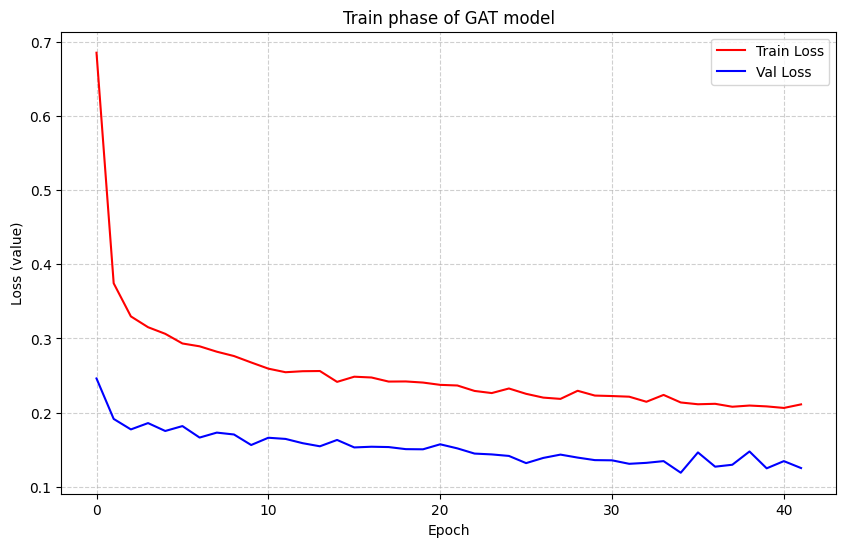

In [77]:
plt.figure(figsize=(10, 6))

plt.plot(train_loss_graph, color='r', label='Train Loss') 
plt.plot(val_loss_graph, color='b', label='Val Loss')

plt.title('Train phase of GAT model')
plt.xlabel('Epoch')
plt.ylabel('Loss (value)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('models/gat_model_version_00.png', dpi=300, bbox_inches='tight') 
plt.show()

# Evaluation

In [78]:
from sklearn.metrics import classification_report, confusion_matrix
import torch

def final_evaluation(loader):
    model.eval()
    
    # Pre hrany (to nás teraz zaujíma najviac)
    all_edge_preds = []
    all_edge_labels = []
    
    # Ak by si predsa len chcel uzly, musel by si pridať node_head do modelu
    # all_node_preds = []
    # all_node_labels = []
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            # 1. Získaj embeddingy (z)
            # tvoj model teraz vracia len z: z = model(batch.x, batch.edge_index)
            z = model(batch.x, batch.edge_index)
            
            # 2. Hrany - vyhodnotenie pravdivých cieľov (targets)
            if batch.edge_index_targets.numel() > 0:
                # POZOR: Musíme poslať aj batch.x kvôli výpočtu vzdialenosti!
                edge_logits = model.predict_edges(z, batch.edge_index_targets, batch.x)
                edge_scores = torch.sigmoid(edge_logits)
                
                # Prah 0.5 pre existenciu hrany
                edge_preds = (edge_scores > 0.5).float() 
                
                all_edge_preds.extend(edge_preds.cpu().numpy())
                all_edge_labels.extend(batch.y_edges.cpu().numpy())
    
    # Vyhodnotenie
    if len(all_edge_labels) > 0:
        print("\n--- VÝSLEDKY PRE HRANY (Logické prepojenia) ---")
        # Výpis Precision, Recall a F1-skóre pre hrany
        print(classification_report(all_edge_labels, all_edge_preds, 
                                    target_names=['Bez prepojenia', 'Logická hrana']))
        
        print("\n--- MATICA ZÁMEN (Confusion Matrix) ---")
        print(confusion_matrix(all_edge_labels, all_edge_preds))
    else:
        print("\n--- VÝSLEDKY PRE HRANY: Žiadne cieľové hrany v sete ---")

# Spusti vyhodnotenie
final_evaluation(test_loader)


--- VÝSLEDKY PRE HRANY (Logické prepojenia) ---
                precision    recall  f1-score   support

Bez prepojenia       0.98      0.94      0.96      3060
 Logická hrana       0.88      0.96      0.92      1479

      accuracy                           0.94      4539
     macro avg       0.93      0.95      0.94      4539
  weighted avg       0.95      0.94      0.94      4539


--- MATICA ZÁMEN (Confusion Matrix) ---
[[2870  190]
 [  63 1416]]


# Save Model

In [79]:
torch.save(model.state_dict(), 'models/gat_model_version_01_0.92_f1.pt')

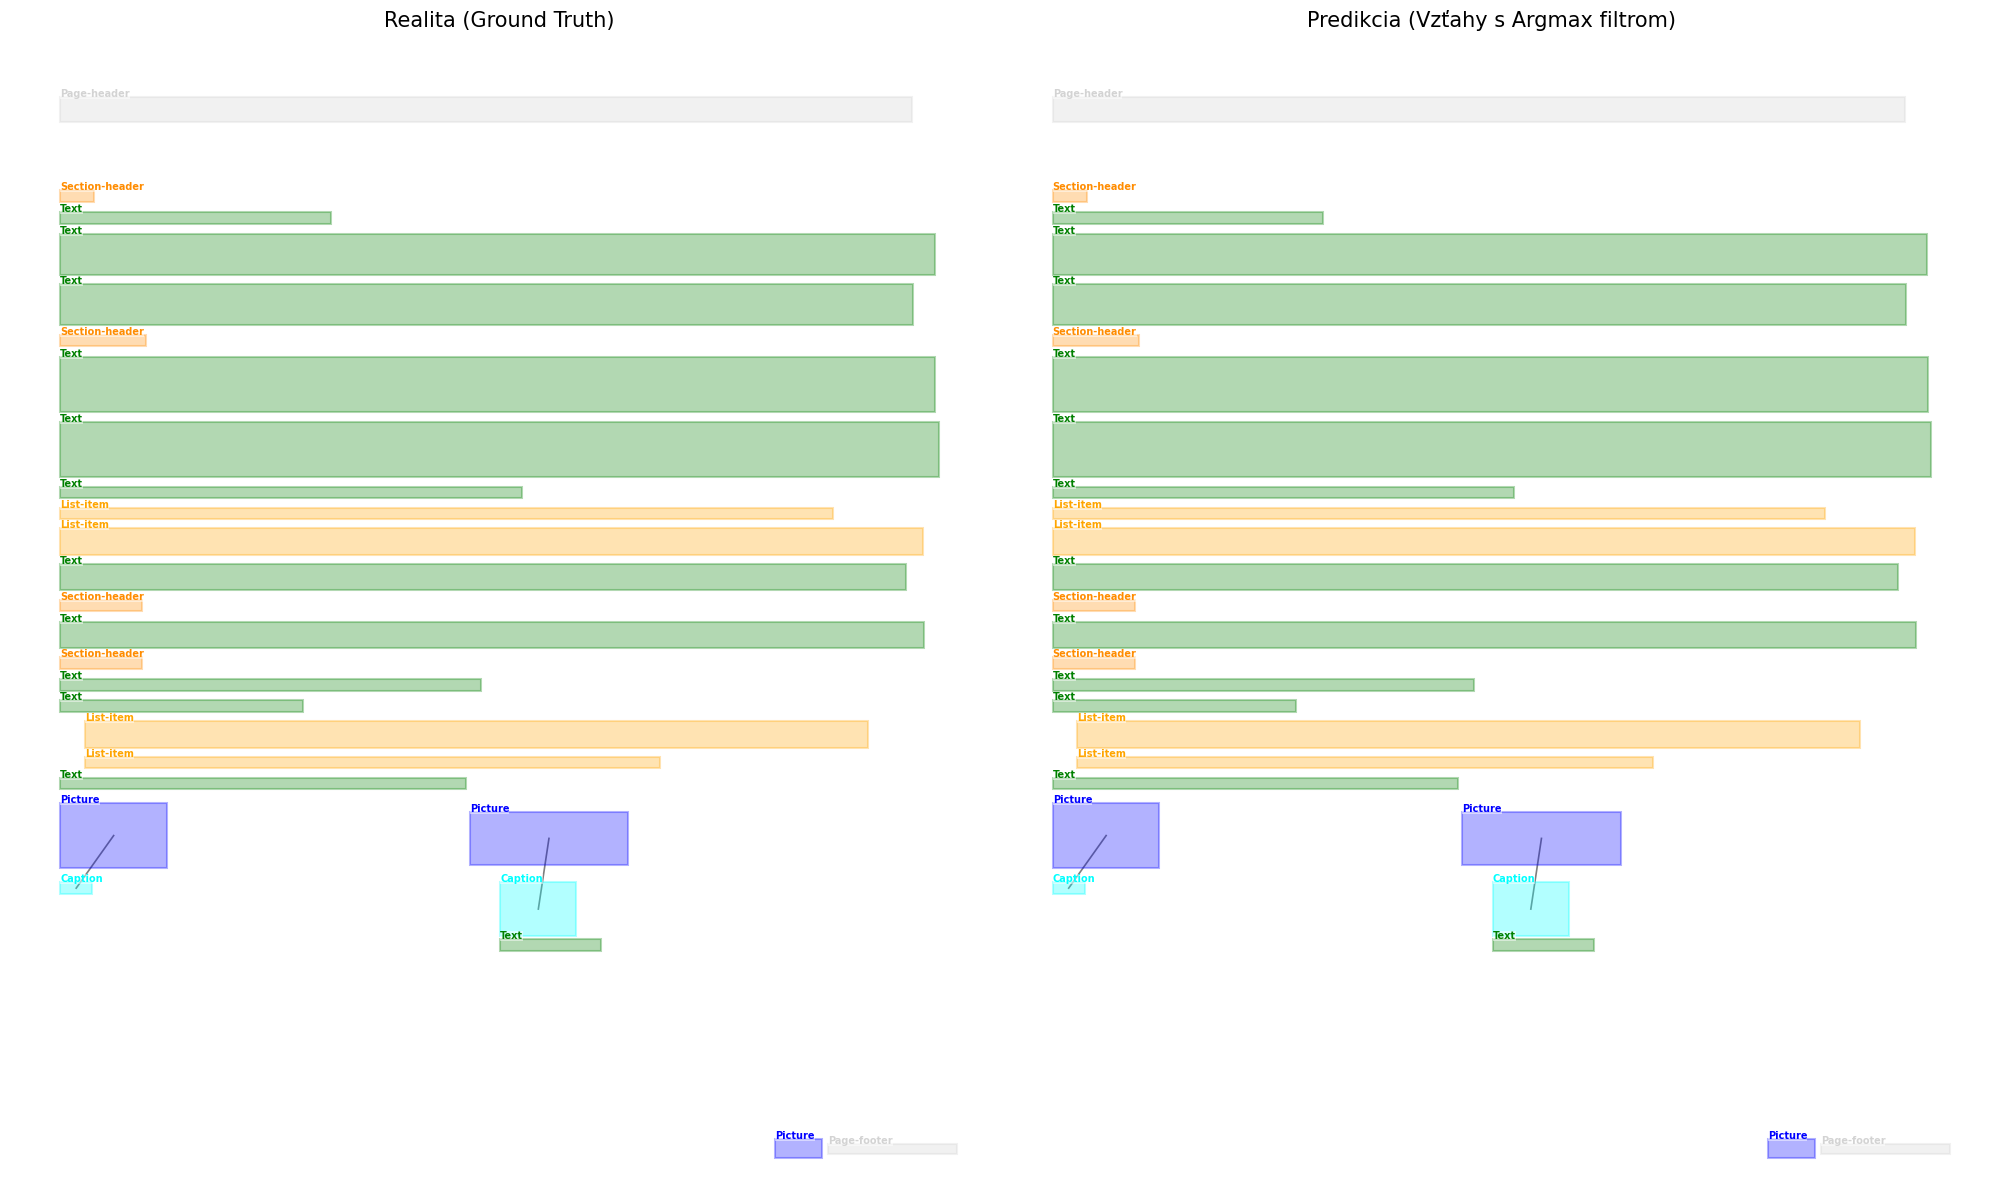

In [88]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import numpy as np

# Definition of legends
class_names = [
    "Caption", "Footnote", "Formula", "List-item", "Page-footer", 
    "Page-header", "Picture", "Section-header", "Table", "Text", "Title"
]

def visualize_multiclass(data_obj):
    model.eval()
    data_obj = data_obj.to(device)
    
    with torch.no_grad():
        z = model(data_obj.x, data_obj.edge_index)
        
        node_preds_for_viz = data_obj.y_nodes.cpu().numpy() 
        
        edge_preds = []
        if data_obj.edge_index_targets.numel() > 0:
   
            edge_logits = model.predict_edges(z, data_obj.edge_index_targets, data_obj.x)
            edge_probs = torch.sigmoid(edge_logits)
            
            # --- POST-PROCESSING: ARGMAX FILTER PRE CAPTION ---
            # Pre každý zdrojový uzol (napr. Caption) necháme len hranu s najvyššou pravdepodobnosťou
            final_edge_mask = torch.zeros_like(edge_probs, dtype=torch.bool)
            
            # Získame unikátne indexy zdrojových uzlov, ktoré majú aspoň jednu predpovedanú hranu (>0.5)
            potential_srcs = data_obj.edge_index_targets[0, edge_probs > 0.5].unique()
            
            for src in potential_srcs:
                # Nájdeme všetky hrany vychádzajúce z tohto uzla
                mask = (data_obj.edge_index_targets[0] == src)
                if mask.any():
                    # Vyberieme index tej s najvyššou pravdepodobnosťou
                    max_idx = torch.where(mask, edge_probs, torch.tensor(-1.0).to(device)).argmax()
                    if edge_probs[max_idx] > 0.5:
                        final_edge_mask[max_idx] = True
            
            edge_preds = final_edge_mask.cpu().numpy()
        else:
            edge_preds = []

    features = data_obj.x.cpu().numpy()
    targets = data_obj.edge_index_targets.cpu().numpy()
    node_types_gt = features[:, 6:].argmax(axis=1) 

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 12))
    
    color_map = {
        0: 'cyan', 1: 'gray', 2: 'purple', 3: 'orange', 4: 'lightgray',
        5: 'lightgray', 6: 'blue', 7: 'darkorange', 8: 'red', 9: 'green', 10: 'orange'
    }

    def draw_scene(ax, n_classes, e_labels, title, is_prediction=False):
        ax.set_title(title, fontsize=15)
        
        # 1. Kreslenie hrán
        if len(e_labels) > 0:
            for i, exists in enumerate(e_labels):
                if exists: # Teraz je to boolean maska
                    u, v = targets[0, i], targets[1, i]
                    ax.plot([features[u, 0], features[v, 0]], [features[u, 1], features[v, 1]], 
                            color='black', alpha=0.5, linewidth=1.2, zorder=1)

        # 2. Kreslenie uzlov a TEXTU
        for i in range(len(n_classes)):
            xc, yc, w, h = features[i, 0], features[i, 1], features[i, 2], features[i, 3]
            orig_type = node_types_gt[i]
            color = color_map.get(orig_type, 'gray')
            label_text = class_names[orig_type]

            # Vykreslenie boxu
            rect = patches.Rectangle((xc - w/2, yc - h/2), w, h, linewidth=1.5,
                                     edgecolor=color, facecolor=color, alpha=0.3, zorder=2)
            ax.add_patch(rect)
            
            if label_text:
                ax.text(xc - w/2, yc - h/2, label_text, color=color, fontsize=7, 
                        fontweight='bold', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0))
        
        ax.set_xlim(0, 1); ax.set_ylim(1, 0); ax.axis('off')

    draw_scene(ax1, node_types_gt, data_obj.y_edges.cpu().numpy(), "Realita (Ground Truth)")
    draw_scene(ax2, node_types_gt, edge_preds, "Predikcia (Vzťahy s Argmax filtrom)", is_prediction=True)

    plt.tight_layout()
    plt.show()

# use on discrete graph
visualize_multiclass(test_graphs[142])